# DREAMS Nodal Hosting Capacity

nodal hosting capacity and plots...

demand (load), and generation (pv) tests

primary and secondary

In [1]:
import dreams

import matplotlib.pyplot as plt
from pathlib import Path
import os

# load feeder

In [2]:
model_dir = Path(r'models') / r'sfo_p1udt1469'

output_dir = model_dir / 'temp_outputs'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [3]:
feeder = dreams.Feeder(model_dir/'Main.dss', name='sfo_p1udt1469')

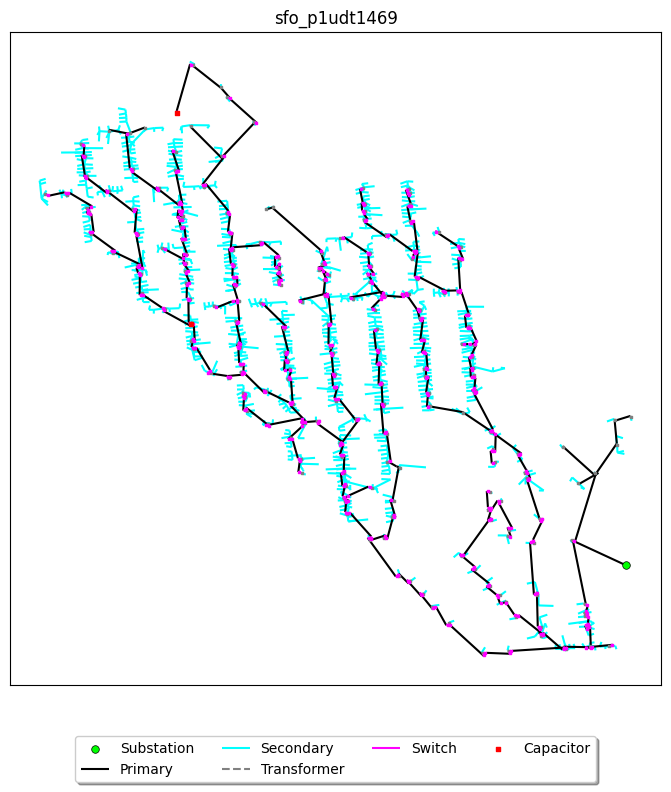

In [4]:
fig, ax = feeder.plot(kind='topo')


# identify buses to test

In [5]:
# identify 3 phase primary buses
primary_buses = feeder.buses['primary']
three_phase = feeder.buses['n_phases'] == 3
mask = primary_buses & three_phase
buses_to_test = feeder.buses[mask].index.values

# thin down bus selection for speed of demo
slice_step = int(len(buses_to_test)/10)
primary_buses = buses_to_test[2::slice_step]  # start at 2 to avoid source test

In [6]:
# select secondary buses
secondary_bus_mask = ~feeder.buses['primary']
buses_to_test = feeder.buses[secondary_bus_mask].index.values

# thin down buses to test for speed
slice_step = int(len(buses_to_test)/10)
secondary_buses = buses_to_test[::slice_step]

# run load hosting capacity
default action is demand voltage constrained hosting capaity

In [7]:
voltage_hc = dreams.hc.NodalSnapshot(feeder, bus_names=primary_buses)
thermal_hc = dreams.hc.NodalSnapshot(feeder, bus_names=primary_buses, constraint='thermal')


Started voltage constrained hosting capacity
Bus 11/11  (100.00% complete in 20.42 seconds)  
Started thermal constrained hosting capacity
Bus 11/11  (100.00% complete in 21.12 seconds)  


In [8]:
sec_voltage_hc = dreams.hc.NodalSnapshot(feeder, bus_names=secondary_buses)
sec_thermal_hc = dreams.hc.NodalSnapshot(feeder, bus_names=secondary_buses, constraint='thermal')


Started voltage constrained hosting capacity
Bus 11/11  (100.00% complete in 21.27 seconds)  
Started thermal constrained hosting capacity
Bus 11/11  (100.00% complete in 18.58 seconds)  


# run pv hosting capacity

In [9]:
pv_voltage_hc = dreams.hc.NodalSnapshot(feeder, bus_names=primary_buses, hc_kind='pv')
pv_thermal_hc = dreams.hc.NodalSnapshot(feeder, bus_names=primary_buses, hc_kind='pv', constraint='thermal')

Started voltage constrained hosting capacity
Bus 11/11  (100.00% complete in 19.80 seconds)  
Started thermal constrained hosting capacity
Bus 11/11  (100.00% complete in 19.70 seconds)  


In [10]:
pv_sec_voltage_hc = dreams.hc.NodalSnapshot(feeder, bus_names=secondary_buses, hc_kind='pv')
pv_sec_thermal_hc = dreams.hc.NodalSnapshot(feeder, bus_names=secondary_buses, hc_kind='pv', constraint='thermal')

Started voltage constrained hosting capacity
Bus 11/11  (100.00% complete in 20.17 seconds)  
Started thermal constrained hosting capacity
Bus 11/11  (100.00% complete in 20.72 seconds)  


# Plotting

additional plot may be a topo style plot... with size/color/shape for display distinctions

Text(0.5, 0.98, 'Load Hosting Capacity')

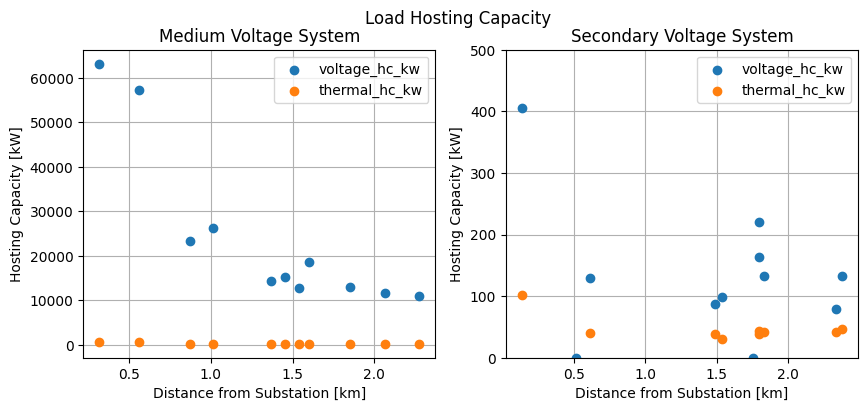

In [11]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,4))

voltage_hc.plot(ax=axes[0])
thermal_hc.plot(ax=axes[0])
axes[0].set_title('Medium Voltage System')

sec_voltage_hc.plot(ax=axes[1])
sec_thermal_hc.plot(ax=axes[1])
axes[1].set_ylim([0,500])  # to remove outliers
axes[1].set_title('Secondary Voltage System')
fig.suptitle('Load Hosting Capacity')
# normal plots not actually distance from sub...

# violation plots

Text(0.5, 0.98, 'Load Hosting Capacity')

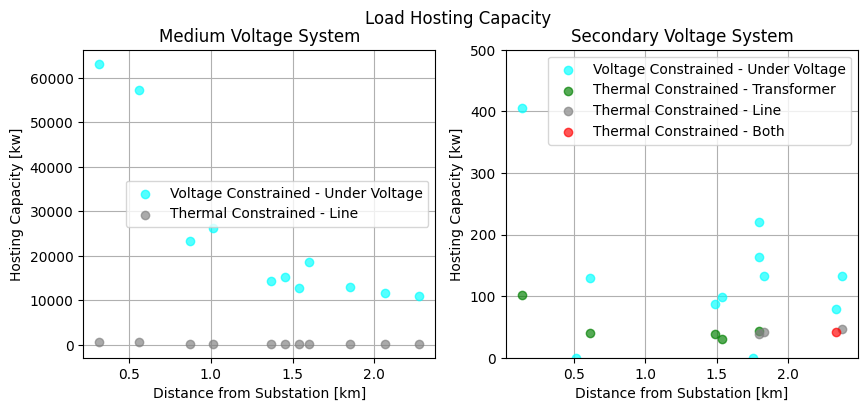

In [12]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,4))

voltage_hc.plot(kind='violation', ax=axes[0])
thermal_hc.plot(kind='violation', ax=axes[0])
axes[0].set_title('Medium Voltage System')

sec_voltage_hc.plot(kind='violation', ax=axes[1])
sec_thermal_hc.plot(kind='violation', ax=axes[1])
axes[1].set_ylim([0,500])  # to remove outliers
axes[1].set_title('Secondary Voltage System')

# ensure zero included
for ax in axes:
    ylims = ax.get_ylim()
    if ylims[0] > 0:
        ax.set_ylim([0, ylims[1]])

fig.suptitle('Load Hosting Capacity')

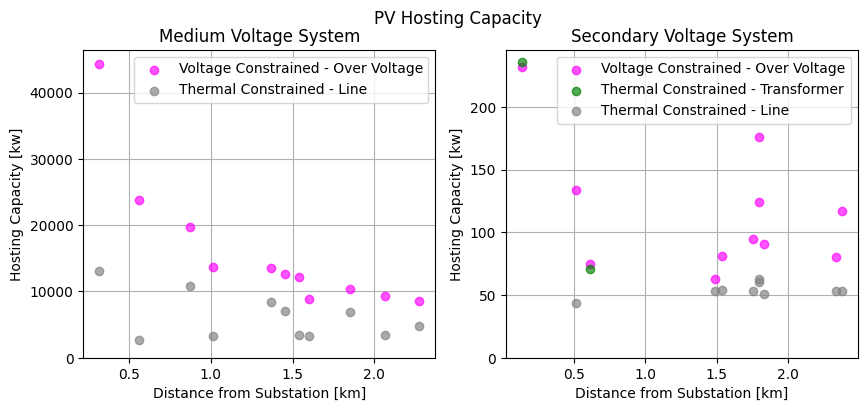

In [13]:

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,4))

pv_voltage_hc.plot(kind='violation', ax=axes[0])
pv_thermal_hc.plot(kind='violation', ax=axes[0])
axes[0].set_title('Medium Voltage System')

pv_sec_voltage_hc.plot(kind='violation', ax=axes[1])
pv_sec_thermal_hc.plot(kind='violation', ax=axes[1])
axes[1].set_title('Secondary Voltage System')
fig.suptitle('PV Hosting Capacity')

# ensure zero included
for ax in axes:
    ylims = ax.get_ylim()
    if ylims[0] > 0:
        ax.set_ylim([0, ylims[1]])